# PHYS-467 Machine Learning for Physicists

Gradient Descent

## Gradient Descent
1.   Load the MNIST dataset and pre-process it;
2.   Compute the gradient analitycally
3.   Write a function that performs gradient descent with $l_2$ regularized binary cross-entropy;
4.   Plot the train and validation loss;
5.   Compute the test MSE and 0/1 loss.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt 

*1. Load MNIST and pre-process it* 

In [ ]:
from keras.datasets import mnist

(X_train, y_train), (X_test, y_test) = mnist.load_data() # load the MNIST dataset through keras

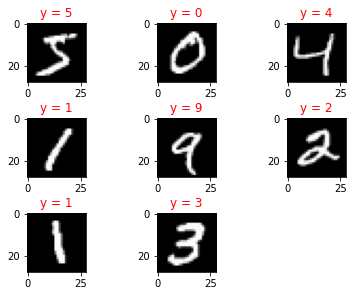

In [ ]:
# display the first 8 digits of the dataset

for i in range(8):  
    plt.subplot(3, 3,  i + 1) # create the plot container
    plt.imshow(X_train[i], cmap=plt.get_cmap('gray')) # plot the image
    plt.tight_layout(pad = 0.3) # add space between subplots
    plt.title("y = " + str(y_train[i]), color = 'red') # print labels as a title
plt.show() # show the plot

In [ ]:
# get info on the dataset
# print shapes of the inputs, of the labels and the maximum and minimum pixel value for both train and test set
#### YOUR CODE GOES HERE ####

In [ ]:
# split the dataset in train/test/validation set

from sklearn.model_selection import train_test_split
#### YOUR CODE GOES HERE ####

In [ ]:
# print again the shapes of the inputs in train, test and validation set

#### YOUR CODE GOES HERE ####

In [ ]:
# pre-process the dataset
def dataset_preprocessing(X_train, y_train, X_val, y_val, X_test, y_test, relabelling_type = "even-odd_digits"):
    """
    This function pre-process the train, test and validation datasets.
    Input:   (X_train, y_train), (X_test, y_test), (X_val, y_val) = train/test/validation set 
            relabelling_type =  partition type of the MNIST dataset. Supported types: even/odd digits, greater/smaller than 5 digits.
    Output:  pre-processed dataset """
    # rescale the inputs in 0-1
    X_train = X_train/255
    X_val = X_val/255
    X_test = X_test/255

    # put images in a vector rather than a matrix
    X_train = np.reshape(X_train, (len(X_train), 28*28))
    X_val = np.reshape(X_val, (len(X_val), 28*28))
    X_test = np.reshape(X_test, (len(X_test), 28*28))

    # rescale the data in order to have pre-activations of order 1
    X_train = X_train/np.sqrt(784)
    X_val = X_val/np.sqrt(784)
    X_test = X_test/np.sqrt(784)

    # relabel MNIST to be suitable for a binary classifier  
    if relabelling_type == "greater-smaller-than-five_digits":
        y_train[y_train <= 5.] = 0
        y_train[y_train > 5.] = 1
        y_val[y_val <= 5.] = 0
        y_val[y_val > 5.] = 1
        y_test[y_test <= 5.] = 0
        y_test[y_test > 5.] = 1
    elif relabelling_type == "even-odd_digits":
        #### YOUR CODE GOES HERE ####

    return X_train, y_train, X_val, y_val, X_test, y_test

X_train, y_train, X_val, y_val, X_test, y_test = dataset_preprocessing(X_train, y_train, X_val, y_val, X_test, y_test, relabelling_type="even-odd_digits")

In [ ]:
# look how the dataset has been changed (print shapes of the inputs, of the labels and the maximum and minimum pixel value for both train and test set)

print("X_train shape = ", np.shape(X_train), "----------------", "y_train shape = ", np.shape(y_train))
print("max pixel value in X_train = ", X_train.max(), "---------------", "min pixel value in X_train = ", X_train.min())
print("")
print("X_val shape = ", np.shape(X_val), "----------------", "y_val shape = ", np.shape(y_val))
print("max pixel value in X_val = ", X_val.max(), "---------------", "min pixel value in X_val = ", X_val.min())
print("")
print("X_test shape = ", np.shape(X_test), "----------------", "y_test shape = ", np.shape(y_test))
print("max pixel value in X_test = ", X_test.max(), "---------------", "min pixel value in X_test = ", X_test.min())

### Recap about Logistic Regression
In the logistic model one assumes \begin{equation}
P(y=1|w,x)=\hat y(x)=\frac{1}{1+e^{- w^Tx}}=\sigma(w^Tx),
\end{equation} 
where $\sigma$ is called the sigmid function.
Given some data $y=(y_1,\dots,y_n),\,y\in\{0,1\}$ and $X\in\mathbb R^{n\times d}$
the likelihood of the data is then $P(y|w,X)=\prod_{\mu=1}^d \hat y(X_\mu)^{y_\mu}+(1-\hat y(X_\mu))^{1-y_\mu}$. 

Taking the logarithm one sees that this is equivalent to the maximization of $\sum_\mu y_\mu \log \hat y(X_\mu)+(1-y_\mu) \log(1- \hat y(X_\mu))$, and hence equivalent to the minimization of the cross entropy loss
$$H(y_\mu,\hat y_\mu)=- y_\mu \log \hat y(X_\mu)+(1-y_\mu) \log(1- \hat y(X_\mu)).$$ The training loss for the whole dataset will then be $L_{train}(y,\hat y)=\frac{1}{n}\sum_{\mu=1}^nH(y_\mu,\hat y_\mu)$.



Note that while this loss emerges naturally when the generative process for $(X,y)$ is the one described by $P(y=1|w,X)$, however in practice people apply it to any data. 

We will also add an $\ell_2$ regularization to the weights, so that the final loss to be optimized is 

$$\mathcal L(w)=L_{train}(w)+\lambda ||w||^2$$

#### Gradient Descent theory
2. To compute the gradient, complete the missing parts below:

$$\frac{\partial H}{\partial \hat y}=...$$

$$\frac{\partial \hat y(x)}{\partial w_i}=...$$

$$
\frac{\partial H}{\partial w_i}=\frac{\partial H}{\partial \hat y}\frac{\partial \hat y(x)}{\partial w_i}=...
$$

$$\frac{\partial \mathcal L}{\partial w_i}=\sum_{\mu=1}^n\frac{\partial H}{\partial w_i}(y_\mu,\hat y(X_\mu))+\lambda \frac{\partial ||w||^2}{\partial w_i} = ... $$

3. Write gradient descent algorithm

In [1]:
import time
import pandas as pd
from sklearn.metrics import mean_squared_error

In [ ]:
# write down the gradient descent algorithm

def sigmoid(x):
    """
    This function computes the sigmoid of the pre-activations.
    Input:  x = variable of interest.
    Output: sig = sigmoid.  
    """

  #### YOUR CODE GOES HERE ####
    return sig

def binary_cross_entropy_loss(y, y_pred):
    """
    This function computes the binary cross entropy loss given the dataset and the actual estimator. 
    Input: y = actual label;
            y_pred = predicted label.
    Output: bc = binary cross-entropy loss averaged over the dataset.
    """

    #### YOUR CODE GOES HERE ####

    return bc

def gradient(X, y, y_pred):
    """
    This function computes the gradient of the binary-cross entropy loss with respect to the weights and averages the gradient across the whole dataset. This should not include the regularization term
    Input: (X, y) = dataset;
            y_pred = predicted labels.
    Output: grad=mean of the gradient across the dataset
    """
    #### YOUR CODE GOES HERE ####

    return grad
    
def run_gd(X, y, X_val, y_val, lamb, eta, epochs, tol, frequency, verbose, n_iter_no_change):
    """
    This function runs the gradient descent algorithm and saves the results on file.
    Input: (X, y), (X_val, y_val) = train and validation set;
            lamb = regularization strength;
            eta = learning rate;
            epochs = maximum number of iterations;
            tol = tolerance;
            frequency = frequency at which the results are printed on the screen;
            verbose = flag to decide whether to print or not information about the algorithm convergence;
            n_iter_no_change = number of iterations we want to wait when the train loss starts not changing more than tol accross the epochs (then the dynamics will be stopped). 
    Output: W = estimated weights 
    """  

    res = {"epoch": [], "train_loss": [], "val_loss": [], "gradient_norm": []} # initialize an empty disctionary where to save results  
    W = np.random.normal(0., 1., size = (len(X[0]))) # initialize the weights
    counter_train = 0
    train_loss_prec = 100

    for epoch in range(epochs): # loop over epochs    
        # compute the gradient and update the weights    
        #### YOUR CODE GOES HERE ####


        # compute the metrics (train and validation losses, norm of the gradient) for the new estimator
        #### YOUR CODE GOES HERE ####

        # save the results by populating the dictionary res
       #### YOUR CODE GOES HERE ####

        # check whether the algorithm is converging    
        if epoch % frequency == 0 and verbose == 1: # display results
            print("epoch: ", epoch, "train loss = ", train_loss, "val loss = ", val_loss, "gradient_norm = ", norm_grad)
        if np.abs(train_loss_prec - train_loss)/eta <= tol: # check whether the loss is not moving
            counter_train += 1 # update the counter
            if counter_train >= n_iter_no_change: # check whether the loss has not changed in a certain time interval 
                print("GD converged to tolerance %.8f"%tol)
            break # if yes exit the loop
        else:
            counter_train = 0

        train_loss_prec = train_loss # assign to the previous training loss its actual value

    res = pd.DataFrame.from_dict(res) # translate the dictionary into a pandas dataframe
    res.to_csv("./training_gd.csv", mode = 'w', index = False) # write the csv file
    return W  

In [ ]:
# Run GD
n = 1000
X_train_slice = X_train[:n]
y_train_slice = y_train[:n]
eta = 0.1
epochs = 1500
lamb = 1e-5
tol = 1e-5
frequency = 1
verbose = 1
n_iter_no_change = 5

start = time.time() # starting time
W_gd = run_gd(X_train_slice, y_train_slice, X_val, y_val, lamb, eta, epochs, tol, frequency, verbose, n_iter_no_change)
print("total computational time in seconds = ", time.time() - start) # print how much the algorithm took to run for a number of epochs = epochs

*4. Plot train and validation loss* 

In [ ]:
# plot the results (i.e. plot train and validation loss as a function of the epoch)
    #### YOUR CODE GOES HERE ####

5. Compute the test mean square loss and 0/1 loss.

For the 0/1 loss one needs to have a hard criterion for classification (i.e. either the classifier outputs 0 or 1, and nothing in between). Convince yourself that it makes sense to take $\hat y_{hard}(x)=\Theta(\hat y(x)-1/2)$.

In [ ]:
# compute the test error for the gd estimators
    #### YOUR CODE GOES HERE ####
test_mse_gd = 
test_01_gd = 
print("The MSE associated to the estimator computed by GD is: ", test_mse_gd) # print it
print("The 0/1 loss associated to the estimator computed by GD is:", test_01_gd) # 

## Stochastic gradient descent

6.   Write a function that performs stochastic gradient descent algoritm (batch size = 10) with $l_2$ regularized binary cross-entropy;
7.   Plot the training loss versus epochs for both gradient descent and stochastic gradient descent;
8.   Compute the test MSE and 0/1 loss

6. Write a function that performs Stochastic Gradient Descent (SGD) (namely
mini-batch GD with batch size = 10) with binary cross-entropy loss and
$\ell_2$ regularization. 
Split the training set into batches of the desired size, then in each epoch (i.e. in each pass over the dataset) select batches in a random order and use them to update the weights. The function `np.random.permutation` might help

In [ ]:
def run_sgd(X, y, X_val, y_val, lamb, eta, epochs, tol, frequency, verbose, n_iter_no_change, batch_size):
    """
    This function run the stochastic gradient descent algorithm and save results on file.
    Input: (X, y), (X_val, y_val) = train and validation set;
            lamb = regularization strength;
            eta = learning rate;
            epochs = maximum number of passes over the whole dataset;
            tol = convergence tolerance;
            frequency = frequency at which the results are printed on the screen;
            verbose = flag to decide whether to print or not information about the algorithm convergence;
            n_iter_no_change = number of iterations we want to wait when the train loss starts not changing more than tol accross the epochs
            batch_size = size of the SGD batches
    Output: W = estimated weights
    """  


    res = {"epoch": [], "train_loss": [], "val_loss": [], "gradient_norm": []} # initialize an empty disctionary where to save results  
    W = np.random.normal(0., 1., size = (len(X[0]))) # initialize the weights
    
    #### YOUR CODE GOES HERE ####

    res = pd.DataFrame.from_dict(res) # translate the dictionary into a pandas dataframe
    res.to_csv("./training_sgd.csv", mode = 'w', index = False) # write the csv file
    return W  

In [ ]:
# Run SGD 
start = time.time() # starting time
epochs=1500
W_sgd = run_sgd(X_train_slice, y_train_slice, X_val, y_val, lamb, eta, epochs, tol, frequency, verbose, n_iter_no_change, batch_size=10)
print("total computational time in seconds = ", time.time() - start) # print how much the algorithm took to run for a number of epochs = epochs

7. plot train losses for both GD and SGD

---



In [ ]:
# plot the train loss for both gd and sgd
    #### YOUR CODE GOES HERE ####


8.  Compute the mean square error and 0/1 loss of SGD and compare with those of GD

In [ ]:
# compute the test error for sgd

    #### YOUR CODE GOES HERE ####


9. Use scikit learn’s built in function for logistic regression to obtain the
estimator. Compute and print test MSE and 0/1 test loss.


In [ ]:
from sklearn.linear_model import LogisticRegression

In [ ]:
    #### YOUR CODE GOES HERE ####